<a href="https://colab.research.google.com/github/magonz3003-eng/Motor_Predictive_Maintenance_Data/blob/main/Motor_Predictive_Maintenance_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('motor_predictive_maintenance_data.csv')
df.head()

,Timestamp,Motor_Temp_C,Vibration_Hz,Current_Amp,Cycle_Count,Failure_Label
0,2026-02-10 22:00:00,87.355530,51.618363,19.290263,990,1
1,2026-01-23 18:00:00,46.154144,12.446079,11.199548,546,0
2,2026-01-05 23:00:00,46.503866,15.194090,11.782257,119,0
3,2026-01-15 10:00:00,42.103831,13.903725,12.188550,346,0
4,2026-01-13 06:00:00,45.714031,15.732640,11.955819,294,0


In [ ]:
from sklearn.model_selection import train_test_split

# We drop 'Timestamp' because the AI only needs the technical numbers
# We drop 'Failure_Label' from X because that's the "answer key"
X = df.drop(['Timestamp', 'Failure_Label'], axis=1)
y = df['Failure_Label']

# Split: 80% to study, 20% for the final test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully. Ready to train.")

Data split successfully. Ready to train.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using our training data
model.fit(X_train, y_train)

print("Training complete. The AI has learned the patterns.")

Training complete. The AI has learned the patterns.


In [ ]:
from sklearn.metrics import classification_report

# Ask the AI to predict
predictions = model.predict(X_test)

# Print the score card
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       159
           1       1.00      1.00      1.00        41

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



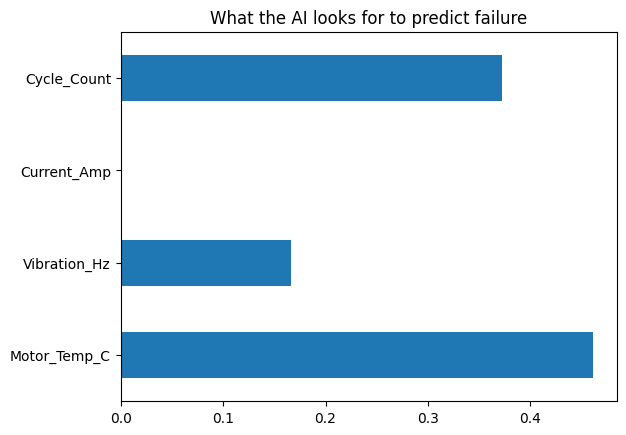

In [ ]:
import matplotlib.pyplot as plt
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.plot(kind='barh')
plt.title('What the AI looks for to predict failure')
plt.show()